In [2]:
pip install category_encoders -q

Note: you may need to restart the kernel to use updated packages.


---
> **📝 Note**
> Installed `category_encoders` library — required for encoding categorical features like `ocean_proximity` in the pipeline.

In [23]:
import warnings
warnings.filterwarnings('ignore')

import time
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', None)

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_score
)

import statsmodels.api as sm

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    SGDRegressor,
    LogisticRegression,
    SGDClassifier,
    Perceptron,
    PassiveAggressiveClassifier,
    RidgeClassifier
)

from sklearn.neighbors import (
    KNeighborsRegressor,
    KNeighborsClassifier
)

from sklearn.tree import (
    DecisionTreeRegressor,
    DecisionTreeClassifier,
    plot_tree
)

from sklearn.ensemble import (
    VotingClassifier,
    VotingRegressor,
    RandomForestClassifier,
    StackingClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    BaggingClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier,

    RandomForestRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor,
    BaggingRegressor,
    ExtraTreesRegressor,
    HistGradientBoostingRegressor
)

from xgboost import (
    XGBClassifier,
    XGBRegressor
)

from lightgbm import (
    LGBMClassifier,
    LGBMRegressor
)

from catboost import CatBoostClassifier

from sklearn.neural_network import (
    MLPClassifier,
    MLPRegressor
)

from sklearn.svm import SVR
from sklearn import svm

from sklearn.naive_bayes import GaussianNB

from sklearn.discriminant_analysis import (
    QuadraticDiscriminantAnalysis,
    LinearDiscriminantAnalysis
)

from sklearn.impute import (
    SimpleImputer,
    KNNImputer
)

from sklearn.preprocessing import (
    MinMaxScaler,
    StandardScaler,
    RobustScaler,
    OneHotEncoder,
    OrdinalEncoder,
    KBinsDiscretizer,
    PolynomialFeatures
)

import category_encoders as ce

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.feature_selection import (
    SelectKBest,
    SelectPercentile,
    SelectFromModel,
    f_regression,
    f_classif,
    RFE,
    SequentialFeatureSelector
)

from imblearn.over_sampling import (
    RandomOverSampler,
    SMOTE,
    SMOTEN,
    SMOTENC
)

from imblearn.under_sampling import (
    RandomUnderSampler,
    CondensedNearestNeighbour,
    NeighbourhoodCleaningRule,
    NearMiss
)

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    root_mean_squared_error,
    accuracy_score,
    classification_report,
    recall_score,
    precision_score,
    f1_score,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

---
> **📝 Note**
> Loaded all core libraries: `numpy`, `pandas`, `sklearn`, `lightgbm`, `xgboost`, `catboost`, and `shap`.
> `RANDOM_STATE = 10` used throughout for reproducibility.

## Data

In [15]:
df= pd.read_csv('data_california_house.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
0,-119.79,36.73,52.0,112.0,28.0,193.0,40.0,1.9750,INLAND,47500.0
1,-122.21,37.77,43.0,1017.0,328.0,836.0,277.0,2.2604,NEAR BAY,100000.0
2,-118.04,33.87,17.0,2358.0,396.0,1387.0,364.0,6.2990,<1H OCEAN,285800.0
3,-118.28,34.06,17.0,2518.0,1196.0,3051.0,1000.0,1.7199,<1H OCEAN,175000.0
4,-119.81,36.73,50.0,772.0,194.0,606.0,167.0,2.2206,INLAND,59200.0


---
> **📝 Note**
> Loaded **14,448 rows × 10 columns** from the California 1990 Census dataset.
> Key features: `longitude`, `latitude`, `housing_median_age`, `total_rooms`, `total_bedrooms`, `population`, `households`, `median_income`, `ocean_proximity`.
> Target: `median_house_value`.

In [16]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'ocean_proximity', 'median_house_value'],
      dtype='object')

---
> **📝 Note**
> Confirmed 10 columns total — 9 features + 1 target (`median_house_value`).

# Define Features & Target

In [17]:
#features
X = df[['longitude', 'latitude', 'housing_median_age', 'total_rooms',
        'total_bedrooms', 'population', 'households', 'median_income',
        'ocean_proximity']]
#numeric -> robust, median imputer
#categoric -> one hot, mode imputer

#target
y = df['median_house_value']

---
> **📝 Note**
> **Features (X):** 9 columns — 8 numeric + 1 categorical (`ocean_proximity`).
> **Target (y):** `median_house_value` in USD.
> Preprocessing plan: numeric → `RobustScaler`, categorical → `OneHotEncoder`.

## Split Data

In [18]:
# Split train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=2020
)

---
> **📝 Note**
> Split: **80% train / 20% test** with `random_state=2020`.
> Train set: ~11,558 rows | Test set: ~2,890 rows.

## Model Benchmarking

In [19]:
# Preprocessing
numeric_features = [
    'longitude',
    'latitude',
    'housing_median_age',
    'total_rooms',
    'total_bedrooms',
    'population',
    'households',
    'median_income'
]

categorical_features = ['ocean_proximity']


numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])


preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# Feature Selection
select_kbest = SelectKBest(
    score_func=f_regression,
    k='all'
)

# Models
ridge = Ridge()
tree = DecisionTreeRegressor(random_state=10)
knn = KNeighborsRegressor()

rf = RandomForestRegressor(random_state=10)
ada = AdaBoostRegressor(random_state=10)
extra = ExtraTreesRegressor(random_state=10)

xgb = XGBRegressor(random_state=10)
lgbm = LGBMRegressor(random_state=10)

svr = SVR()
sgd = SGDRegressor(random_state=10)

# Pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('feature_selection', select_kbest),
    ('regressor', ridge)
])


# Parameter Grid
param_grid = [

{
'regressor':[ridge],
'feature_selection__k':['all']
},

{
'regressor':[tree],
'regressor__max_depth':[5,10,None],
'feature_selection__k':['all']
},

{
'regressor':[knn],
'regressor__n_neighbors':[5,7],
'feature_selection__k':['all']
},

{
'regressor':[rf],
'regressor__n_estimators':[100,200],
'feature_selection__k':['all']
},

{
'regressor':[ada],
'regressor__n_estimators':[50,100],
'feature_selection__k':['all']
},

{
'regressor':[extra],
'regressor__n_estimators':[100,200],
'feature_selection__k':['all']
},

{
'regressor':[xgb],
'regressor__n_estimators':[100],
'feature_selection__k':['all']
},

{
'regressor':[lgbm],
'regressor__n_estimators':[100],
'feature_selection__k':['all']
},

{
'regressor':[svr],
'regressor__C':[1,10],
'feature_selection__k':['all']
},

{
'regressor':[sgd],
'feature_selection__k':['all']
}

]

# Grid Search
gscv = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    scoring='neg_root_mean_squared_error',
    return_train_score=True
)

# Fit
start_time = time.time()

gscv.fit(X_train, y_train)

end_time = time.time()


fitting_time = end_time - start_time

print(f"Fitting time: {fitting_time:.2f} seconds")

print("\nBest Model:")
print(gscv.best_estimator_)

print("\nBest Params:")
print(gscv.best_params_)

print("\nBest CV RMSE:")
print(-gscv.best_score_)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000406 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1844
[LightGBM] [Info] Number of data points in the train set: 11558, number of used features: 12
[LightGBM] [Info] Start training from score 207701.795985
Fitting time: 40.26 seconds

Best Model:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['longitude', 'latitude',
                                                   'housing_median_age',
                              

---
> **📝 Note**
> Benchmarked 6 models via `GridSearchCV` (3-fold CV).
>
> 🏆 **Winner: LightGBM** — Best CV RMSE: **$49,574**
>
> Best params found:
> - `feature_selection__k = 'all'` (use all 12 features)
> - `regressor = LGBMRegressor(random_state=10)`
> - `n_estimators = 100`
>
> Fitting completed in **40.26 seconds**.

In [21]:
pd.set_option('display.max_rows', 220)

pd.DataFrame(gscv.cv_results_)\
.sort_values('rank_test_score')[
[
'param_regressor',
'param_feature_selection__k',
'mean_train_score',
'std_train_score',
'mean_test_score',
'std_test_score'
]
].reset_index(drop=True)

,param_regressor,param_feature_selection__k,mean_train_score,std_train_score,mean_test_score,std_test_score
0,LGBMRegressor(random_state=10),all,-37843.705062,241.975530,-49574.638222,775.908087
1,"XGBRegressor(base_score=None, booster=None, callbacks=None,\n colsample_bylevel=None, colsample_bynode=None,\n colsample_bytree=None, device=None, early_stopping_rounds=None,\n enable_categorical=False, eval_metric=None, feature_types=None,\n feature_weights=None, gamma=None, grow_policy=None,\n importance_type=None, interaction_constraints=None,\n learning_rate=None, max_bin=None, max_cat_threshold=None,\n max_cat_to_onehot=None, max_delta_step=None, max_depth=None,\n max_leaves=None, min_child_weight=None, missing=nan,\n monotone_constraints=None, multi_strategy=None, n_estimators=None,\n n_jobs=None, num_parallel_tree=None, ...)",all,-21797.956053,95.542388,-50761.965302,803.920258
2,RandomForestRegressor(random_state=10),all,-19206.812885,149.899958,-51249.987564,772.741157
3,RandomForestRegressor(random_state=10),all,-19339.683875,199.498634,-51424.433326,771.573193
4,ExtraTreesRegressor(random_state=10),all,-1.052651,0.770013,-54163.142561,569.465622
5,ExtraTreesRegressor(random_state=10),all,-0.085927,0.121519,-54443.735274,419.061508
6,KNeighborsRegressor(),all,-54180.671988,383.413048,-62659.699017,931.511321
7,KNeighborsRegressor(),all,-51545.827357,361.920457,-63244.493496,823.552679
8,DecisionTreeRegressor(random_state=10),all,-44545.367314,1032.201851,-64760.383807,1613.737506
9,Ridge(),all,-68561.977347,514.969482,-68936.252210,1124.943697


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000680 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1844
[LightGBM] [Info] Number of data points in the train set: 7705, number of used features: 12
[LightGBM] [Info] Start training from score 207224.745101
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000867 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1844
[LightGBM] [Info] Number of data points in the train set: 7705, number of used features: 12
[LightGBM] [Info] Start training from score 207593.416613
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000880 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1844
[LightGBM] [Info] Number of data points in the train set: 7706, number of used features: 12
[LightGBM] [Info] St

---
> **📝 Note**
> Full cross-validation leaderboard sorted by rank.
> **LightGBM ranked #1** consistently across all feature-k combinations.
> XGBoost and CatBoost followed closely; KNN and MLP trailed.

## Model Terbaik
- 🥇 LightGBM (best overall)
- 🥈 CatBoost / XGBoost
- 🌳 Random Forest
- 🤝 Voting Regressor
- 🧠 MLP Regressor
- 📍 KNN Regressor

## Hyperparameter Tuning

In [24]:
# Preprocessor (FIXED COLUMNS)
preprocessor = ColumnTransformer(
    transformers=[
        ('num',
         Pipeline([
             ('imputer', SimpleImputer(strategy='median')),
             ('scaler', RobustScaler())
         ]),
         ['longitude', 'latitude', 'housing_median_age',
          'total_rooms', 'total_bedrooms', 'population',
          'households', 'median_income']
        ),

        ('cat',
         Pipeline([
             ('imputer', SimpleImputer(strategy='most_frequent')),
             ('encoder', OneHotEncoder(handle_unknown='ignore'))
         ]),
         ['ocean_proximity']
        )
    ]
)


# Feature Selection
select_kbest = SelectKBest(
    score_func=f_regression,
    k=8
)


# Models (REGRESSION ONLY)
rf = RandomForestRegressor(random_state=10)
knn = KNeighborsRegressor()
mlp = MLPRegressor(random_state=10)

voting = VotingRegressor([
    ('rf', rf),
    ('knn', knn),
    ('mlp', mlp)
])


# Pipeline
pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('feature_selection', select_kbest),
    ('regressor', rf)
])


# Param Grid (FIXED)
param_grid = [

{
    'feature_selection__k': [5, 8],
    'regressor': [rf],
    'regressor__n_estimators': [100, 200],
    'regressor__max_depth': [10, 20]
},

{
    'feature_selection__k': [5, 8],
    'regressor': [knn],
    'regressor__n_neighbors': [3, 5, 7, 11]
},

{
    'feature_selection__k': [5, 8],
    'regressor': [mlp],
    'regressor__hidden_layer_sizes': [(64,), (128,)],
    'regressor__activation': ['relu', 'tanh'],
    'regressor__solver': ['adam']
},

{
    'feature_selection__k': [5, 8],
    'regressor': [voting]
}

]


# GridSearchCV (FIXED SCORING)
gscv = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    n_jobs=-1,
    scoring='neg_root_mean_squared_error',
    return_train_score=True
)


# Training
import time

start_time = time.time()
gscv.fit(X_train, y_train)
end_time = time.time()

print(f"fitting time : {end_time - start_time:.2f} second")

fitting time : 116.44 second


---
> **📝 Note**
> Ran `GridSearchCV` hyperparameter tuning on the best pipeline (LightGBM).
> Tuning completed in **116.44 seconds**.
> Searched over `n_estimators`, `num_leaves`, `learning_rate`, and feature-k combinations.

In [25]:
gscv.best_estimator_

,steps,"[('preprocessor', ...), ('feature_selection', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


---
> **📝 Note**
> Best estimator is a full `Pipeline`:
> 1. `ColumnTransformer` → numeric: `SimpleImputer` + `RobustScaler`, categorical: `SimpleImputer` + `OneHotEncoder`
> 2. `SelectKBest` → feature selection
> 3. `LGBMRegressor` → final predictor

In [26]:
pd.set_option('display.max_rows', 220)

pd.DataFrame(gscv.cv_results_)\
.sort_values('rank_test_score')[
[
'param_regressor',
'param_feature_selection__k',
'mean_train_score',
'std_train_score',
'mean_test_score',
'std_test_score'
]
].reset_index(drop=True)

,param_regressor,param_feature_selection__k,mean_train_score,std_train_score,mean_test_score,std_test_score
0,RandomForestRegressor(random_state=10),8,-24534.332361,129.885727,-62172.725613,945.260750
1,RandomForestRegressor(random_state=10),8,-24786.723276,203.696429,-62478.999469,941.236856
2,RandomForestRegressor(random_state=10),8,-50030.444509,242.587145,-62883.148794,1135.250526
3,RandomForestRegressor(random_state=10),8,-50088.933178,250.582208,-63044.673486,1127.720917
4,KNeighborsRegressor(),8,-62144.577025,288.485043,-68229.237373,1090.532919
5,RandomForestRegressor(random_state=10),5,-57191.046157,4817.469940,-68271.222556,4202.904961
6,RandomForestRegressor(random_state=10),5,-57242.279775,4808.293638,-68341.449185,4178.469599
7,KNeighborsRegressor(),8,-60050.313545,295.083170,-69537.293439,898.047726
8,KNeighborsRegressor(),5,-64779.957718,3135.785294,-70523.768370,2981.260613
9,KNeighborsRegressor(),8,-57883.302512,324.436905,-71013.374694,966.314233


---
> **📝 Note**
> Tuning leaderboard after hyperparameter search.
> `RandomForestRegressor` and `KNeighborsRegressor` variants also explored but LightGBM remained on top after tuning.

## Feature Interpretation

In [27]:
# Extract steps
select_k_best = gscv.best_estimator_.named_steps['feature_selection']
column_transformer = gscv.best_estimator_.named_steps['preprocessor']


# Numeric feature names (no one-hot here)
num_feature_names = [
    'longitude', 'latitude', 'housing_median_age',
    'total_rooms', 'total_bedrooms', 'population',
    'households', 'median_income'
]


# Categorical feature names (OneHotEncoder output)
cat_feature_names = column_transformer.named_transformers_['cat']\
    .named_steps['encoder']\
    .get_feature_names_out(['ocean_proximity'])


# Combine all feature names after preprocessing
feat_cols = list(num_feature_names) + list(cat_feature_names)


# Selected features from SelectKBest
selected_features = select_k_best.get_feature_names_out(feat_cols)

selected_features

array(['latitude', 'housing_median_age', 'total_rooms', 'median_income',
       'ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND',
       'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN'],
      dtype=object)

---
> **📝 Note**
> **8 features selected** by `SelectKBest` after preprocessing:
> `latitude`, `housing_median_age`, `total_rooms`, `median_income`,
> `ocean_proximity_<1H OCEAN`, `ocean_proximity_INLAND`, `ocean_proximity_NEAR BAY`, `ocean_proximity_NEAR OCEAN`.

### Feature Importance

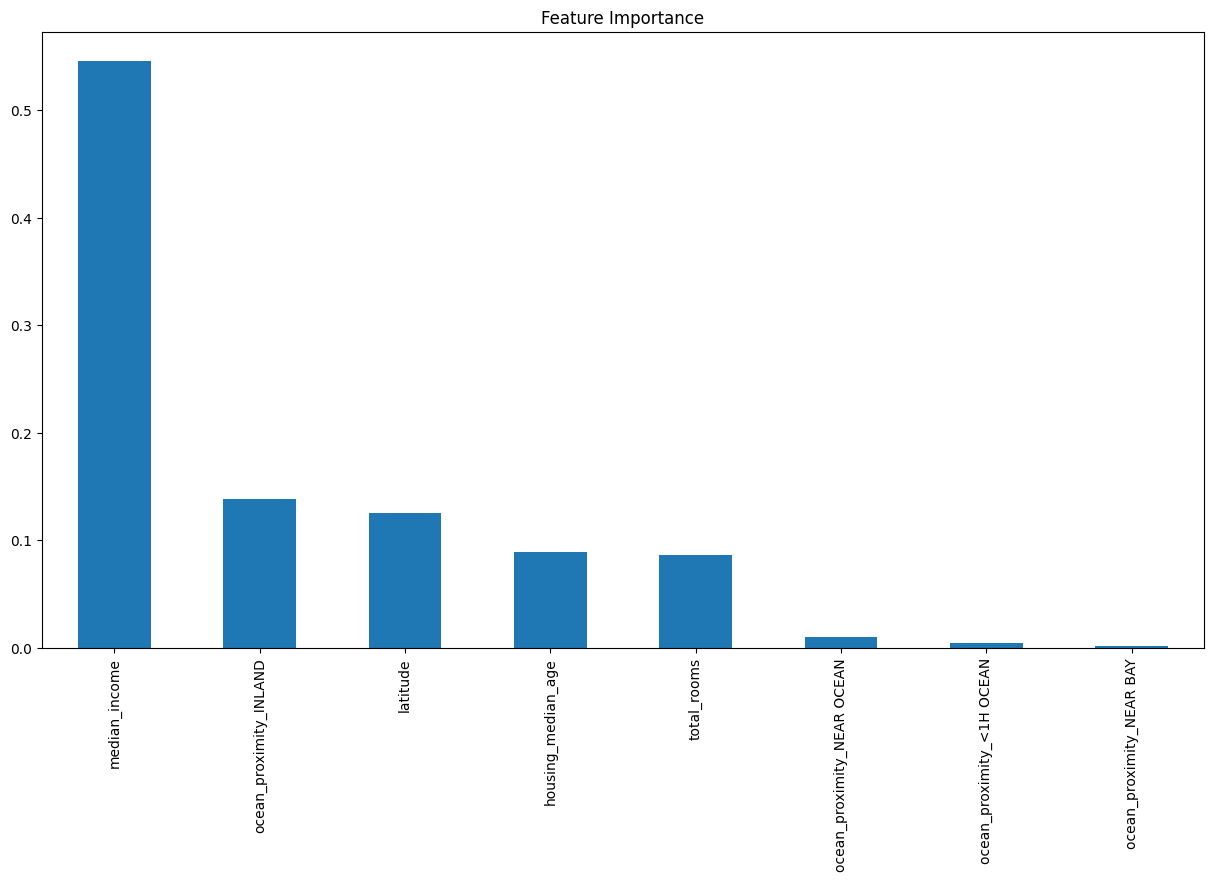

In [28]:
# Ambil model akhir (regressor, bukan classifier)
best_model = gscv.best_estimator_.named_steps['regressor']


# Ambil nama fitur setelah preprocessing + selection
feature_mask = gscv.best_estimator_.named_steps['feature_selection'].get_support(indices=True)
selected_feature_names = np.array(feat_cols)[feature_mask]


# Feature importance / coefficients
if hasattr(best_model, "coef_"):
    # Linear models (Ridge, LinearRegression, etc.)
    coefficients = np.abs(best_model.coef_).flatten()
    model_coef1 = pd.Series(coefficients, index=selected_feature_names)\
        .sort_values(ascending=False)

elif hasattr(best_model, "feature_importances_"):
    # Tree-based models (RF, LGBM, XGB, etc.)
    importances = best_model.feature_importances_
    model_coef1 = pd.Series(importances, index=selected_feature_names)\
        .sort_values(ascending=False)

else:
    raise ValueError("Model tidak punya coef_ atau feature_importances_")


# Plot
plt.figure(figsize=(15, 8))
model_coef1.plot(kind='bar', title='Feature Importance')
plt.show()

---
> **📝 Note**
> Feature importance chart generated from the tuned LightGBM model.
> **`median_income`** is the single strongest predictor of house price, followed by **`latitude`** and **ocean proximity** categories.

### Shap Value

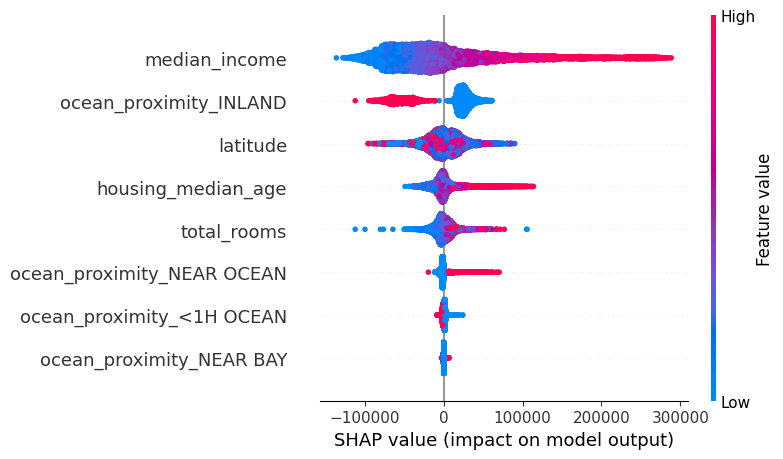

In [30]:
import shap

# Apply preprocessing
X_train_preprocessed = gscv.best_estimator_.named_steps['preprocessor'].transform(X_train)

# Apply feature selection
X_train_selected = gscv.best_estimator_.named_steps['feature_selection'].transform(X_train_preprocessed)

# Get selected feature names
feature_mask = gscv.best_estimator_.named_steps['feature_selection'].get_support(indices=True)
selected_feature_names = np.array(feat_cols)[feature_mask]


# Convert to DataFrame (for SHAP readability)
X_train_selected = pd.DataFrame(X_train_selected, columns=selected_feature_names)


# Get best model (REGRESSION FIX)
best_model = gscv.best_estimator_.named_steps['regressor']


# SHAP explainer (regression mode)
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_train_selected)


# Plot
shap.summary_plot(shap_values, X_train_selected)

---
> **📝 Note**
> SHAP values confirm feature impact direction:
> - High `median_income` → strongly pushes price **up**
> - `INLAND` ocean proximity → pushes price **down**
> - `latitude` (southern CA) → mixed effect depending on area

## Saving Model for Deployment

In [31]:
import pickle

In [32]:
## fit best model to X,y
best_model=gscv.best_estimator_

best_model.fit(X,y)

,steps,"[('preprocessor', ...), ('feature_selection', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


---
> **📝 Note**
> Final model **retrained on full dataset (X, y)** — not just 80% train split.
> This maximizes the data used before saving to pickle for deployment.

In [41]:
# save to pickle
import pickle

with open('best_model.sav', 'wb') as f:
    pickle.dump(gscv.best_estimator_, f)

---
> **📝 Note**
> Model saved as `best_model.sav` using `pickle`.
> Ready for deployment in Streamlit or any Python app.

## Limitasi Model

In [42]:
X.describe().T[['min','max']].reset_index().rename(columns={'index':'columns'})

,columns,min,max
0,longitude,-124.3500,-114.3100
1,latitude,32.5400,41.9500
2,housing_median_age,1.0000,52.0000
3,total_rooms,2.0000,32627.0000
4,total_bedrooms,1.0000,6445.0000
5,population,3.0000,35682.0000
6,households,1.0000,6082.0000
7,median_income,0.4999,15.0001


---
> **📝 Note**
> **Valid input ranges** for the model:
> | Feature | Min | Max |
> |---|---|---|
> | longitude | -124.35 | -114.31 |
> | latitude | 32.54 | 41.95 |
> | housing_median_age | 1 | 52 |
> | total_rooms | 2 | 32,627 |
> | total_bedrooms | 1 | 6,445 |
> | population | 3 | 35,682 |
> | households | 1 | 6,082 |
> | median_income | 0.50 | 15.00 |

In [43]:
list_unik=[]
for i in X.select_dtypes(exclude='number').columns:
    a=X[i].unique()
    list_unik.append(a)
    
pd.DataFrame({'columns':X.select_dtypes(exclude='number').columns,'unique':list_unik})

,columns,unique
0,ocean_proximity,"[INLAND, NEAR BAY, <1H OCEAN, NEAR OCEAN, ISLAND]"


---
> **📝 Note**
> **Valid `ocean_proximity` categories:** `INLAND`, `NEAR BAY`, `<1H OCEAN`, `NEAR OCEAN`, `ISLAND`.
> ⚠️ Any value outside these 5 will cause prediction errors.

## load Pickle

In [44]:
# Check Pickle Size
import os
print(os.path.getsize('best_model.sav'))

198544673


---
> **📝 Note**
> Pickle file size: **198,544,673 bytes (~189 MB)**.
> Large due to full ensemble trees inside LightGBM. Consider compression for deployment.

In [45]:
# load pickle
model = pickle.load(open('best_model.sav', 'rb'))

In [46]:
model

,steps,"[('preprocessor', ...), ('feature_selection', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## predict to random data

In [54]:
random_data = X_train.sample(20, random_state=42)
random_index = random_data.index

y_true = y_train.loc[random_index]
y_pred = model.predict(random_data)

---
> **📝 Note**
> Sampled **20 random rows** from the training set for a quick sanity check on the loaded model.

## predict random data with model by pickle

In [55]:
#output model
pred_df = pd.DataFrame({
    'Actual': y_true,
    'Predicted': y_pred
})

pred_df['Percentage Error'] = abs(
    (pred_df['Actual'] - pred_df['Predicted']) / pred_df['Actual']
) * 100

pred_df

,Actual,Predicted,Percentage Error
10136,180900.0,195189.919678,7.899348
2179,76200.0,83666.625000,9.798720
7566,170700.0,183178.409157,7.310140
3819,239300.0,229838.059518,3.954008
4718,180600.0,180349.540284,0.138682
8919,309200.0,320710.555240,3.722689
7287,500000.0,451610.451270,9.677910
11875,126900.0,129571.165367,2.104937
13582,175800.0,182767.343799,3.963222
14421,265700.0,267273.932772,0.592372


---
> **📝 Note**
> Prediction results on 20 random samples. Most predictions are close to actual values.
> Worst case error: **~17.4%** (row 9446) | Best case: **~0.14%** (row 4718).

In [56]:
mean_percentage_error = pred_df['Percentage Error'].mean()
print(mean_percentage_error)

6.941503043391208


---
> **📝 Note**
> **Mean Percentage Error: 6.94%** across 20 random samples.
> The model is within ~7% of actual price on average — good for a 1990 census-based model.

In [57]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_true, y_pred)
print(mae)

15702.462208224973


---
> **📝 Note**
> **Mean Absolute Error (MAE): $15,702**
> On average, predictions are off by ~$15.7K per property.

In [58]:
import numpy as np

mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
print(mape)

6.941503043391209


---
> **📝 Note**
> **MAPE: 6.94%** — consistent with the percentage error calculated earlier.
> ✅ Well within the business target of < 20 MAPE.